# 05 · Classical baselines — Spark ML

Before any deep learning, a floor. These models read exactly the artefacts built
in notebook 04 — the scaled 194-dimensional `features` vector (187 waveform
samples ⊕ 7 descriptors) and the balanced `class_weight` column — and they run
entirely in Spark ML.

The point is not to win. It is to answer two questions the deep model will be
judged against:

1. **How far do engineered features and a shallow model get?** If a random forest
   on 194 numbers is already close, the convolutions have little to add.
2. **What does the imbalance do to a metric?** The trivial "always answer N"
   model is scored first, on purpose.

```bash
python scripts/train_baselines.py --source mitbih
```

> **Fitting happens in the scripts, not in the notebooks.** Every model here was
> produced by a command shown at the top of its section; the notebook reloads the
> saved model and re-runs inference live, so the tables and figures below come
> from the fitted estimator rather than from a cached CSV that could drift from
> it. That keeps notebook execution fast and the artefacts in `reports/`
> guaranteed consistent with what the repository ships.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

try:
    import ecg
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import ecg

print("ecg", ecg.__version__)

ecg 0.1.0


In [2]:
import pandas as pd

from ecg import baselines as bl
from ecg import eda, metrics, viz
from ecg.config import load_config
from ecg.features import MODEL_FEATURE_COLUMNS
from ecg.preprocessing import load_dataset
from ecg.session import get_spark

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 30)

cfg = load_config()
spark = get_spark(cfg)
spark.sparkContext.setLogLevel("ERROR")
viz.apply_style()

SOURCE = "mitbih"
LABELS = eda.ordered_labels(SOURCE)

dataset = load_dataset(spark, cfg, SOURCE).cache()
frames = bl.split_frames(dataset)
print(f"{dataset.count():,} beats · {len(LABELS)} classes")
dataset.groupBy("split_final").count().orderBy("split_final").show()

109,446 beats · 5 classes


+-----------+-----+
|split_final|count|
+-----------+-----+
|       test|21892|
|      train|74418|
|        val|13136|
+-----------+-----+



## 1 · The number that makes accuracy useless

A model that always answers `N` never looks at the signal. Here is how it scores.

In [3]:
y_test = frames["test"].select("label").toPandas()["label"].to_numpy()

trivial = metrics.majority_class_baseline(y_test, LABELS)
pd.Series(trivial["summary"]).to_frame("majority-class model")

,majority-class model
model,majority-class
split,test
n,21892
macro_f1,0.1811
weighted_f1,0.7495
balanced_accuracy,0.2
accuracy,0.8276
mcc,0.0
cohen_kappa,0.0


In [4]:
trivial["per_class"]

,class,precision,recall,f1,support
0,N,0.8276,1.0000,0.9057,18118
1,S,0.0000,0.0000,0.0000,556
2,V,0.0000,0.0000,0.0000,1448
3,F,0.0000,0.0000,0.0000,162
4,Q,0.0000,0.0000,0.0000,1608
5,macro avg,0.1655,0.2000,0.1811,21892
6,weighted avg,0.6849,0.8276,0.7495,21892


**82.8% accuracy, macro-F1 0.181.** Four of the five classes are never predicted
at all, including every ventricular and fusion beat — the ones a cardiologist
actually needs flagged. Every number below is therefore read as macro-F1 first.

## 2 · Four Spark ML baselines

Two linear models, a bagged tree ensemble and a boosted one, all class-weighted,
all fitted on the same training split.

In [5]:
pd.DataFrame([
    {"model": name, "description": spec.description, **spec.params}
    for name, spec in bl.BASELINES.items()
])

,model,description,maxIter,regParam,numTrees,maxDepth,subsamplingRate,stepSize
0,logistic-regression,"Multinomial logistic regression, L2, class-wei...",100.0,0.01,NaN,NaN,NaN,NaN
1,random-forest,"120 trees, depth 12, sqrt feature subsampling,...",NaN,NaN,120.0,12.0,0.8,NaN
2,linear-svc,"Linear SVM, one-vs-rest for the 5-class task, ...",60.0,0.01,NaN,NaN,NaN,NaN
3,gradient-boosted-trees,"Gradient-boosted trees, one-vs-rest for the 5-...",25.0,NaN,NaN,5.0,NaN,0.1


In [6]:
table = pd.read_csv(cfg.tables_dir / f"{SOURCE}_baselines_test.csv")
table[["model", "macro_f1", "balanced_accuracy", "accuracy", "weighted_f1", "mcc", "fit_seconds"]]

,model,macro_f1,balanced_accuracy,accuracy,weighted_f1,mcc,fit_seconds
0,random-forest,0.8323,0.8654,0.9668,0.9679,0.8903,112.1
1,gradient-boosted-trees,0.6724,0.8870,0.8775,0.8972,0.7045,116.8
2,logistic-regression,0.4971,0.7869,0.6834,0.7477,0.4631,29.7
3,linear-svc,0.4876,0.7908,0.6623,0.7315,0.4536,71.8


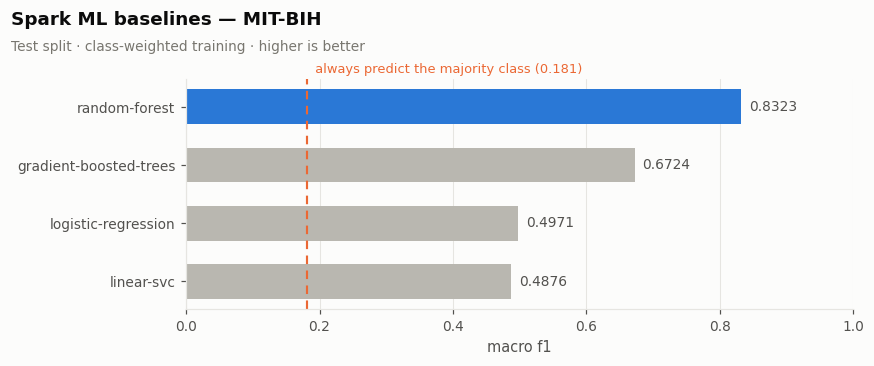

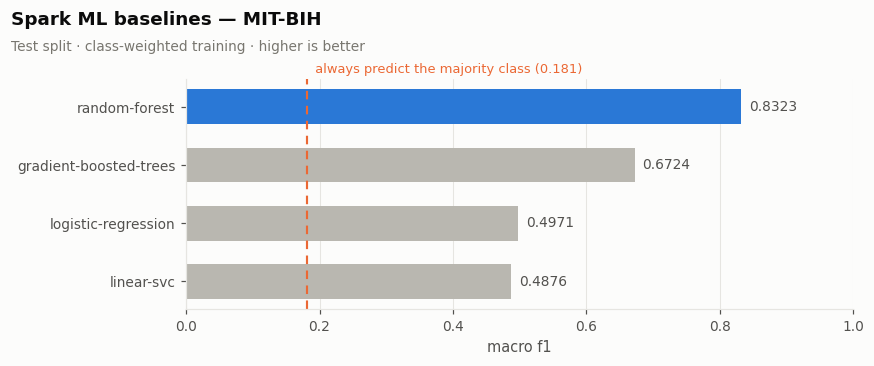

In [7]:
viz.plot_model_comparison(
    table,
    metric="macro_f1",
    title="Spark ML baselines — MIT-BIH",
    subtitle="Test split · class-weighted training · higher is better",
    reference=float(trivial["summary"]["macro_f1"]),
    reference_label="always predict the majority class",
)

**Finding — the split between linear and non-linear is stark.** Logistic
regression and the linear SVM land near macro-F1 0.49; the random forest reaches
0.83. The gap is not the optimiser, it is the decision boundary: the classes are
not linearly separable in this feature space, which is the same conclusion the EDA
reached from the correlation matrix.

**Finding — class weighting trades accuracy for recall, and the trade shows.**
The linear models score *worse than the trivial baseline on accuracy* (0.68 vs
0.83) while scoring far better on macro-F1. That is the weighting doing its job:
it pushes the model to predict rare classes, buys recall on `S`, `V` and `F`, and
pays for it with false positives on `N`. Judging these models by accuracy would
rank them below a model that never looks at the data.

**Finding — balanced accuracy and macro-F1 disagree about the booster.** The
gradient-boosted ensemble has the *highest* balanced accuracy of the four (0.887)
and only the third-best macro-F1 (0.672). Balanced accuracy averages recall alone;
macro-F1 also charges for the false positives that recall was bought with. When
the two disagree, the model is over-predicting rare classes — which is why this
project reports both and ranks on macro-F1.

## 3 · Where the best baseline fails

The saved model is reloaded and inference re-run, so what follows is the fitted
forest and not a stored table.

In [8]:
best_name = table.iloc[0]["model"]
best_model = bl.load_model(cfg, SOURCE, best_name)
print(best_name, "—", bl.BASELINES[best_name].description)
print(type(best_model).__name__)

evaluation = bl.evaluate_baseline(
    best_model, frames["test"], LABELS, bl.BASELINES[best_name], "test"
)
pd.Series(evaluation["summary"]).to_frame(best_name)

random-forest — 120 trees, depth 12, sqrt feature subsampling, class-weighted
RandomForestClassificationModel


,random-forest
model,random-forest
split,test
n,21892
macro_f1,0.8323
weighted_f1,0.9679
balanced_accuracy,0.8654
accuracy,0.9668
mcc,0.8903
cohen_kappa,0.8901
roc_auc_ovr_macro,0.9845


In [9]:
evaluation["per_class"]

,class,precision,recall,f1,support
0,N,0.9796,0.9837,0.9816,18118
1,S,0.8214,0.7032,0.7578,556
2,V,0.9664,0.8930,0.9282,1448
3,F,0.3945,0.7963,0.5276,162
4,Q,0.9826,0.9509,0.9665,1608
5,macro avg,0.8289,0.8654,0.8323,21892
6,weighted avg,0.9706,0.9668,0.9679,21892


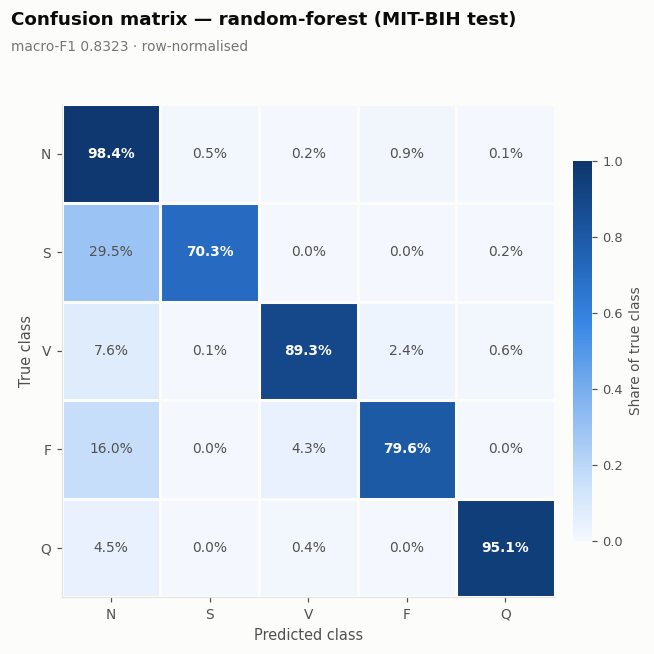

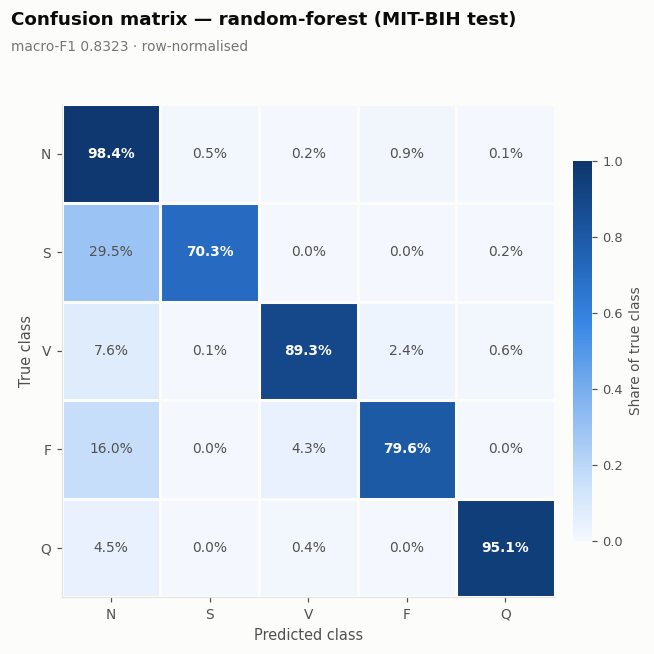

In [10]:
viz.plot_confusion_matrix(
    evaluation["confusion_normalised"],
    title=f"Confusion matrix — {best_name} (MIT-BIH test)",
    subtitle=f"macro-F1 {evaluation['summary']['macro_f1']:.4f} · row-normalised",
    normalised=True,
)

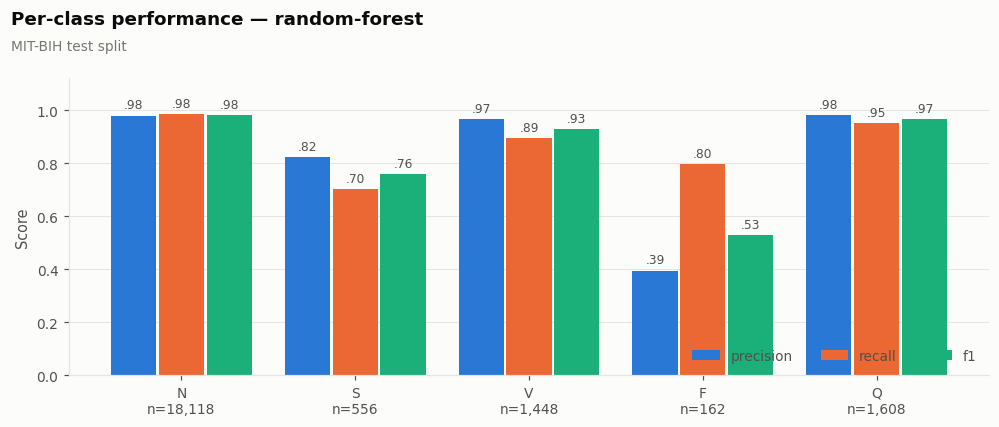

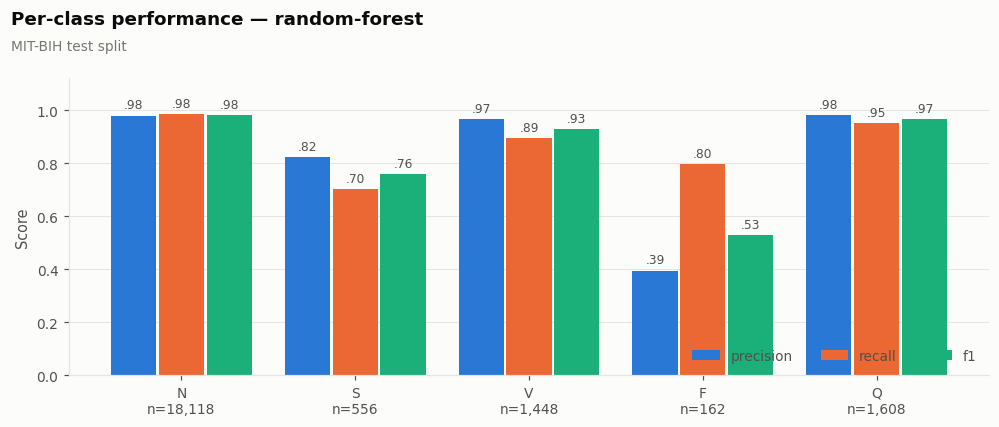

In [11]:
viz.plot_per_class_metrics(
    evaluation["per_class"],
    order=LABELS,
    title=f"Per-class performance — {best_name}",
    subtitle="MIT-BIH test split",
)

**Finding — the two rare classes fail in opposite ways.** `F` is the weakest
(F1 0.528): the forest recalls 80% of fusion beats but only 39% of what it labels
`F` actually is one — of the 327 beats it calls `F`, **163 are normal**. With 162
true fusion beats against 18,118 normal ones, even a 0.9% leak from `N` swamps the
precision. `S` fails the other way (F1 0.758): precision is fine, but it misses 30%
of supraventricular beats, and **164 of its 165 errors go to `N`** — the class whose
median waveform the EDA showed sitting closest to it. `V` and `Q`, the two
morphologically distinct classes, are handled well.

## 4 · What is the forest actually using?

The feature vector is 187 waveform samples followed by 7 descriptors. If the
descriptors dominated the importances, the engineered features would be doing the
work; if the samples dominate, the model is reading shape — badly, one sample at a
time, which is precisely the job a convolution does better.

In [12]:
feature_names = bl.assembled_feature_names(MODEL_FEATURE_COLUMNS)
bl.feature_importances(best_model, feature_names, top_n=15)

,feature,importance,rank
0,s003,0.045162,1
1,s002,0.028858,2
2,max_abs_diff,0.028087,3
3,s004,0.023620,4
4,s001,0.022882,5
5,s005,0.021168,6
6,mean_abs_diff,0.019284,7
7,s006,0.017778,8
8,s000,0.015428,9
9,signal_length,0.014267,10


In [13]:
grouped = (
    bl.feature_importances(best_model, feature_names, top_n=len(feature_names))
    .assign(group=lambda d: d["feature"].where(
        d["feature"].isin(MODEL_FEATURE_COLUMNS), "waveform samples"))
    .groupby("group", as_index=False)["importance"].sum()
    .sort_values("importance", ascending=False)
)
grouped["share_%"] = (grouped["importance"] * 100).round(1)
grouped[["group", "share_%"]].head(10)

,group,share_%
7,waveform samples,91.3
3,max_abs_diff,2.8
4,mean_abs_diff,1.9
6,signal_length,1.4
5,peak_index,1.1
2,amp_std,0.9
0,amp_mean,0.4
1,amp_min,0.1


## Takeaways

| | |
|---|---|
| Trivial baseline | accuracy 0.828, **macro-F1 0.181** — the reason accuracy is never the headline |
| Best classical model | random forest, **macro-F1 0.832** on the test split |
| Linear models | ~0.49 — the classes are not linearly separable in this space |
| Weakest classes | `S` and `F`, exactly as the EDA predicted |
| Bar for the CNN | **beat macro-F1 0.832**, and specifically improve recall on `S` and `F` |

Next: **06 · Residual 1-D CNN**, which drops the engineered features and reads the
187-sample waveform directly.

In [14]:
dataset.unpersist()
spark.stop()